In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(
    r"C:\movies-ml-main\movies-ml-main\data\global_movies_dataset_1950_2026.csv"
)

df.head()

,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,roi_pct,popularity_score,metascore,audience_score,streaming_platform,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag
0,1,Crimson Code,2001,2000,116,Action|Drama|Sci-Fi,Superhero,Denis Villeneuve,Brad Pitt,Tom Hanks,...,98.0,82.54,60,74,Netflix,3,2,0.560,0,0
1,2,Lost Empire,1951,1950,85,Crime|Animation,Gangster,Christopher Nolan,Scarlett Johansson,Brad Pitt,...,139.3,80.54,64,56,MGM+,0,0,0.549,0,0
2,3,Last Legacy,1990,1990,141,Sci-Fi|Drama,Cyberpunk,Bong Joon-ho,Emma Stone,Brad Pitt,...,-45.5,81.98,59,60,Peacock,1,1,0.520,0,0
3,4,Crimson River,1952,1950,82,Mystery|Romance,Whodunit,Quentin Tarantino,Meryl Streep,Tom Hanks,...,57.4,72.10,69,77,Disney+,1,1,0.498,0,0
4,5,Lost Dream,2011,2010,130,Romance,Romantic Drama,Quentin Tarantino,Robert Downey Jr.,Timothee Chalamet,...,97.8,60.63,48,57,Prime Video,0,0,0.435,0,0


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape:
(100000, 27)

Columns:
Index(['movie_id', 'title', 'release_year', 'decade', 'runtime_min', 'genre',
       'subgenre', 'director', 'lead_actor', 'lead_actress', 'country',
       'language', 'imdb_rating', 'votes', 'budget_million',
       'marketing_budget_million', 'revenue_million', 'roi_pct',
       'popularity_score', 'metascore', 'audience_score', 'streaming_platform',
       'award_nominations', 'award_wins', 'top_100_prob', 'blockbuster_flag',
       'franchise_flag'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   movie_id                  100000 non-null  int64  
 1   title                     100000 non-null  str    
 2   release_year              100000 non-null  int64  
 3   decade                    100000 non-null  int64  
 4   runtime_min               10

In [4]:
df.isnull().sum()

movie_id                    0
title                       0
release_year                0
decade                      0
runtime_min                 0
genre                       0
subgenre                    0
director                    0
lead_actor                  0
lead_actress                0
country                     0
language                    0
imdb_rating                 0
votes                       0
budget_million              0
marketing_budget_million    0
revenue_million             0
roi_pct                     0
popularity_score            0
metascore                   0
audience_score              0
streaming_platform          0
award_nominations           0
award_wins                  0
top_100_prob                0
blockbuster_flag            0
franchise_flag              0
dtype: int64

In [5]:
df = df.dropna()

print(df.shape)

(100000, 27)


In [6]:
df.describe()

,movie_id,release_year,decade,runtime_min,imdb_rating,votes,budget_million,marketing_budget_million,revenue_million,roi_pct,popularity_score,metascore,audience_score,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,1988.013390,1983.640400,113.712660,6.736212,4.020426e+04,48.269718,22.966829,133.313829,176.872003,80.080743,66.721890,69.739070,1.645950,0.591140,0.547061,0.225280,0.180420
std,28867.657797,22.217453,22.274525,20.218836,1.014200,5.212749e+04,43.584906,24.086906,196.396971,238.856193,10.169402,15.458479,14.034926,2.018539,1.001581,0.074313,0.417769,0.384539
min,1.000000,1950.000000,1950.000000,70.000000,2.200000,4.250000e+02,0.500000,0.100000,0.060000,-90.000000,33.840000,10.000000,12.000000,0.000000,0.000000,0.219000,0.000000,0.000000
25%,25000.750000,1969.000000,1960.000000,100.000000,6.100000,1.244000e+04,16.070000,6.320000,24.420000,14.800000,73.180000,56.000000,60.000000,0.000000,0.000000,0.497000,0.000000,0.000000
50%,50000.500000,1988.000000,1980.000000,114.000000,6.700000,2.430500e+04,34.860000,14.960000,66.145000,100.900000,80.160000,67.000000,70.000000,1.000000,0.000000,0.547000,0.000000,0.000000
75%,75000.250000,2007.000000,2000.000000,127.000000,7.400000,4.776725e+04,68.000000,31.010000,159.562500,253.925000,87.260000,77.000000,79.000000,2.000000,1.000000,0.597000,0.000000,0.000000
max,100000.000000,2026.000000,2020.000000,205.000000,9.800000,1.539859e+06,284.420000,180.000000,2940.580000,1100.600000,100.000000,100.000000,100.000000,17.000000,9.000000,0.940000,1.000000,1.000000


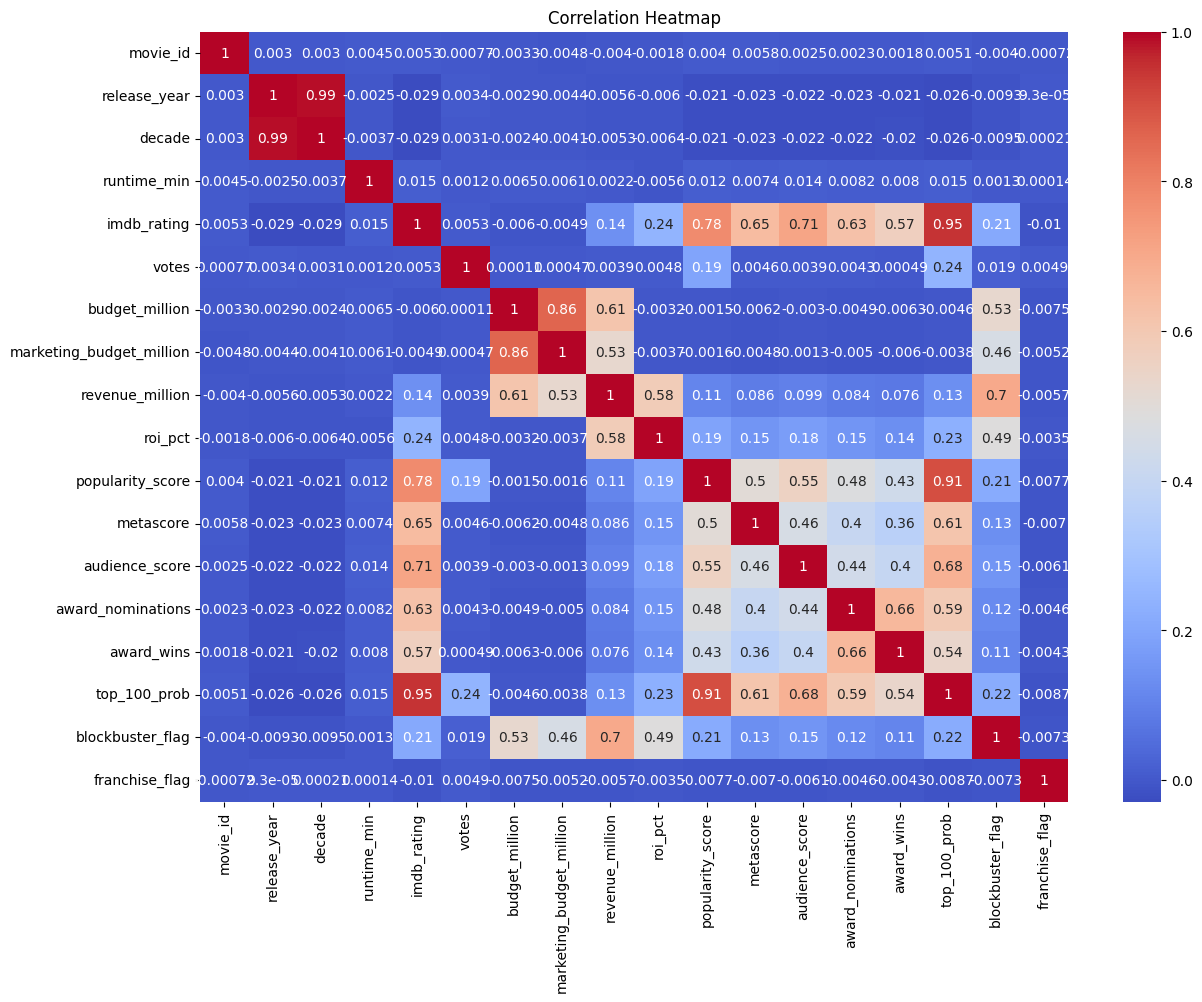

In [7]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    r"C:\movies-ml-main\movies-ml-main\outputs\correlation_heatmap.png"
)

plt.show()

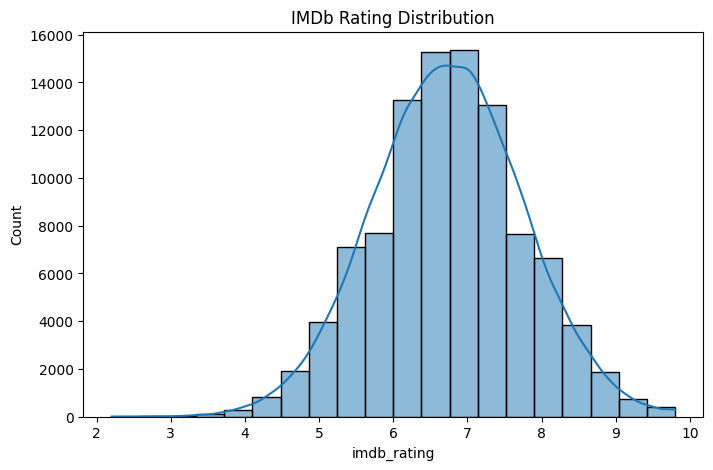

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['imdb_rating'],
    bins=20,
    kde=True
)

plt.title("IMDb Rating Distribution")

plt.savefig(
    r"C:\movies-ml-main\movies-ml-main\outputs\figures\imdb_rating_distribution.png"
)

plt.show()

In [9]:
label_encoder = LabelEncoder()

categorical_cols = [
    'genre',
    'subgenre',
    'director',
    'lead_actor',
    'lead_actress',
    'country',
    'language',
    'streaming_platform'
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(
        df[col].astype(str)
    )

In [ ]:
target = 'imdb_rating'
y = df[target]
features = [
    'release_year',
    'runtime_min',
    'genre',
    'subgenre',
    'director',
    'lead_actor',
    'lead_actress',
    'country',
    'language',
    'votes',
    'budget_million',
    'marketing_budget_million',
    'revenue_million',
    'roi_pct',
    'popularity_score',
    'metascore',
    'award_nominations',
    'award_wins',
    'blockbuster_flag',
    'franchise_flag'
]

X = df[features]
y = df[target]

NameError: name 'df' is not defined

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [15]:
def evaluate_model(name, y_test, predictions):

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print("-"*30)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    return [name, mae, rmse, r2]

In [16]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)


Linear Regression
------------------------------
MAE : 0.00529796000093333
RMSE: 0.026136733396769807
R2 Score: 0.9993418300790888

Random Forest
------------------------------
MAE : 0.015861600000000378
RMSE: 0.035012830505401875
R2 Score: 0.998818891329734

XGBoost
------------------------------
MAE : 0.0240377752828598
RMSE: 0.04595967198055702
R2 Score: 0.99796488359269


In [17]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.005298,0.026137,0.999342
1,Random Forest,0.015862,0.035013,0.998819
2,XGBoost,0.024038,0.045960,0.997965


In [18]:
results_df.to_csv(
    "C:\\movies-ml-main\\movies-ml-main\\outputs\\tables\\model_results.csv",
    index=False
)

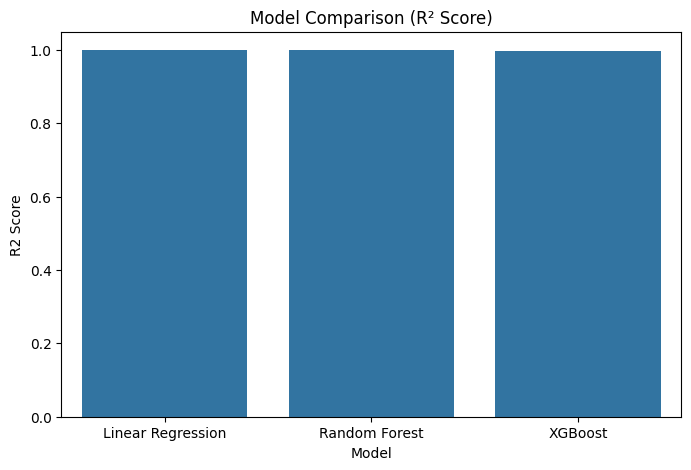

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df
)

plt.title("Model Comparison (R² Score)")

plt.savefig(
    "C:\\movies-ml-main\\movies-ml-main\\outputs\\figures\\model_comparison.png"
)

plt.show()

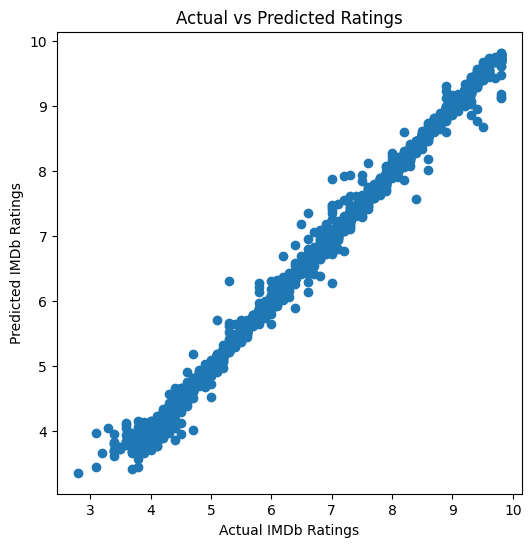

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, xgb_pred)

plt.xlabel("Actual IMDb Ratings")
plt.ylabel("Predicted IMDb Ratings")

plt.title("Actual vs Predicted Ratings")

plt.savefig(
    "C:\\movies-ml-main\\movies-ml-main\\outputs\\figures\\actual_vs_predicted.png"
)

plt.show()